In [1]:
!pip install xgboost shap

  Using cached numpy-2.5.0-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
  Using cached numpy-2.4.6-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
  Using cached numpy-2.2.6-cp312-cp312-win_amd64.whl.metadata (60 kB)
Using cached numpy-2.2.6-cp312-cp312-win_amd64.whl (12.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4


  You can safely remove it manually.
  You can safely remove it manually.

[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve
)

from xgboost import XGBClassifier

import shap

In [3]:
df = pd.read_csv("../Data/online_retail_feature_engineered.csv")

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Year,Month,...,AverageSpend,LifetimeSales,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,2009,12,...,28.4544,2134.08,13085.0,158,8,2134.08,3,4,5,345
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009,12,...,28.4544,2134.08,13085.0,158,8,2134.08,3,4,5,345
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009,12,...,28.4544,2134.08,13085.0,158,8,2134.08,3,4,5,345
3,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,2009,12,...,28.4544,2134.08,13085.0,158,8,2134.08,3,4,5,345
4,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom,2009,12,...,28.4544,2134.08,13085.0,158,8,2134.08,3,4,5,345


In [4]:
df["Churn"] = np.where(df["Recency"] > 90, 1, 0)

df["Churn"].value_counts()

Churn
0    513026
1    150347
Name: count, dtype: int64

In [5]:
features = [
    "Recency",
    "Frequency",
    "Monetary"
]

X = df[features]

y = df["Churn"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [7]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    eval_metric="logloss"
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [8]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

In [10]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", round(accuracy,4))

Accuracy : 1.0


In [11]:
precision = precision_score(y_test, y_pred)

print("Precision :", round(precision,4))

Precision : 1.0


In [12]:
recall = recall_score(y_test, y_pred)

print("Recall :", round(recall,4))

Recall : 1.0


In [13]:
roc = roc_auc_score(y_test, y_prob)

print("ROC AUC :", round(roc,4))

ROC AUC : 1.0


In [14]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    102606
           1       1.00      1.00      1.00     30069

    accuracy                           1.00    132675
   macro avg       1.00      1.00      1.00    132675
weighted avg       1.00      1.00      1.00    132675



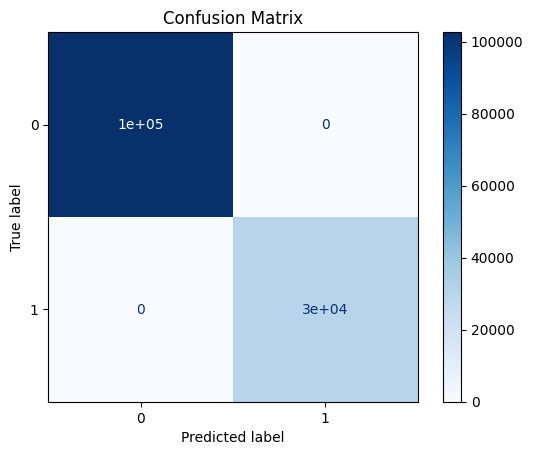

In [15]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

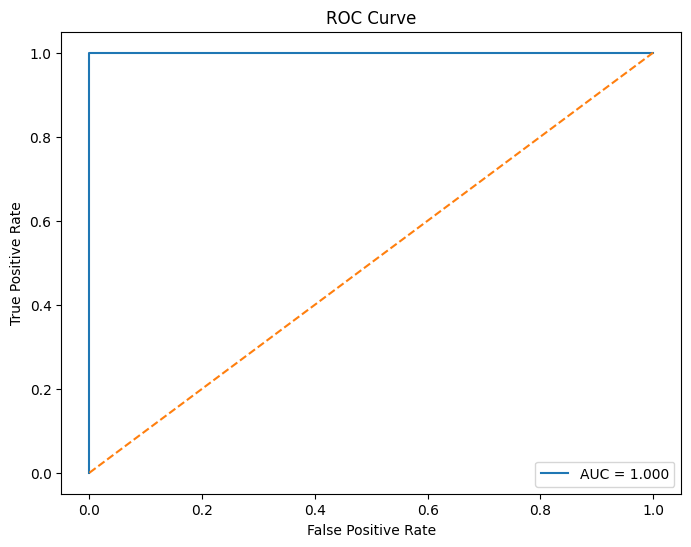

In [16]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"AUC = {roc:.3f}")

plt.plot([0,1], [0,1], "--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [17]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

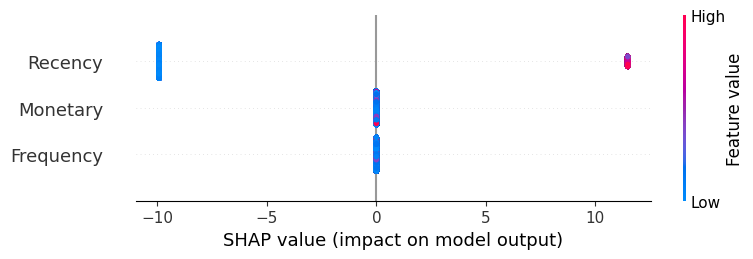

In [18]:
shap.summary_plot(
    shap_values,
    X_test
)

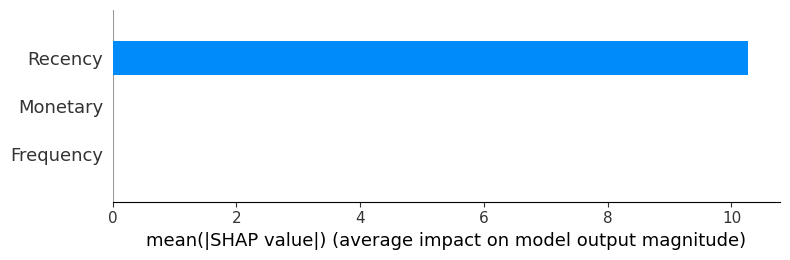

In [19]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

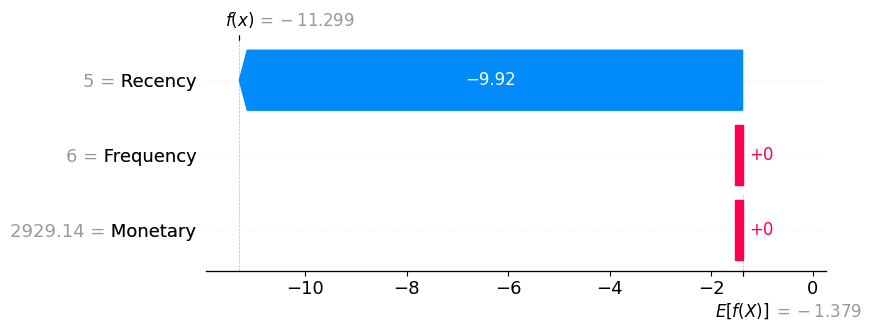

In [20]:
explanation = explainer(X_test)

shap.plots.waterfall(explanation[0])

In [21]:
shap.initjs()

shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test.iloc[0]
)

In [22]:
customer = pd.DataFrame({

    "Recency":[45],

    "Frequency":[12],

    "Monetary":[2500]

})

prediction = model.predict(customer)

probability = model.predict_proba(customer)

print("Prediction :", prediction[0])

print("Probability :", probability[0][1])

Prediction : 0
Probability : 1.2389405e-05


In [23]:
results = X_test.copy()

results["Actual"] = y_test.values

results["Prediction"] = y_pred

results["Probability"] = y_prob

results.to_csv(
    "churn_predictions.csv",
    index=False
)

print("Predictions Saved Successfully")

Predictions Saved Successfully
